In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load IPL datasets

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [6]:
# Display first rows of matches dataset

matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
# Display first rows of deliveries dataset

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [10]:
# Check dataset shapes

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [12]:
# Display matches information

matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [14]:
# Display deliveries information

deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [16]:
# Generate numerical summary

matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [18]:
# Generate categorical summary

matches.describe(include="object")

,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,super_over,method,umpire1,umpire2
count,1095,1044,1095,1095,1090,1095,1095,1095,1095,1095,1090,1095,1095,21,1095,1095
unique,17,36,823,8,291,58,19,19,19,2,19,4,2,1,62,62
top,2013,Mumbai,2017-04-09,League,AB de Villiers,Eden Gardens,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,N,D/L,AK Chaudhary,S Ravi
freq,76,173,2,1029,25,77,135,138,143,704,144,578,1081,21,115,83


In [20]:
# Check missing values in matches

matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [22]:
# Calculate missing value percentage

round(matches.isnull().sum()/len(matches)*100,2)

id                  0.00
season              0.00
city                4.66
date                0.00
match_type          0.00
player_of_match     0.46
venue               0.00
team1               0.00
team2               0.00
toss_winner         0.00
toss_decision       0.00
winner              0.46
result              0.00
result_margin       1.74
target_runs         0.27
target_overs        0.27
super_over          0.00
method             98.08
umpire1             0.00
umpire2             0.00
dtype: float64

In [24]:
# Check duplicate rows in matches

matches.duplicated().sum()

0

In [26]:
# Check duplicate rows in deliveries

deliveries.duplicated().sum()

0

In [28]:
# Fill missing player awards

matches["player_of_match"] = matches["player_of_match"].fillna("No Award")

In [30]:
# Fill missing dismissal types

deliveries["dismissal_kind"] = deliveries["dismissal_kind"].fillna("Not Out")

In [32]:
# Remove highly missing column

matches.drop("method",axis=1,inplace=True)

In [34]:
# Convert date column into datetime

matches["date"] = pd.to_datetime(matches["date"])

In [36]:
# Extract year from date

matches["year"] = matches["date"].dt.year

In [38]:
# Extract month from date

matches["month"] = matches["date"].dt.month

In [40]:
# Merge datasets for analysis

df = deliveries.merge(
    matches,
    left_on="match_id",
    right_on="id",
    how="left"
)

In [42]:
# Create total runs feature

df["delivery_runs"] = df["batsman_runs"] + df["extra_runs"]

In [44]:
# Create boundary indicator

df["is_boundary"] = np.where(
    df["batsman_runs"]>=4,
    "Boundary",
    "Non-Boundary"
)

In [46]:
# Display merged dataset shape

df.shape

(260920, 40)

In [48]:
# Count matches by season

matches["season"].value_counts()

season
2013       76
2023       74
2012       74
2022       74
2011       73
2024       71
2018       60
2021       60
2020/21    60
2019       60
2016       60
2014       60
2009/10    60
2017       59
2015       59
2007/08    58
2009       57
Name: count, dtype: int64

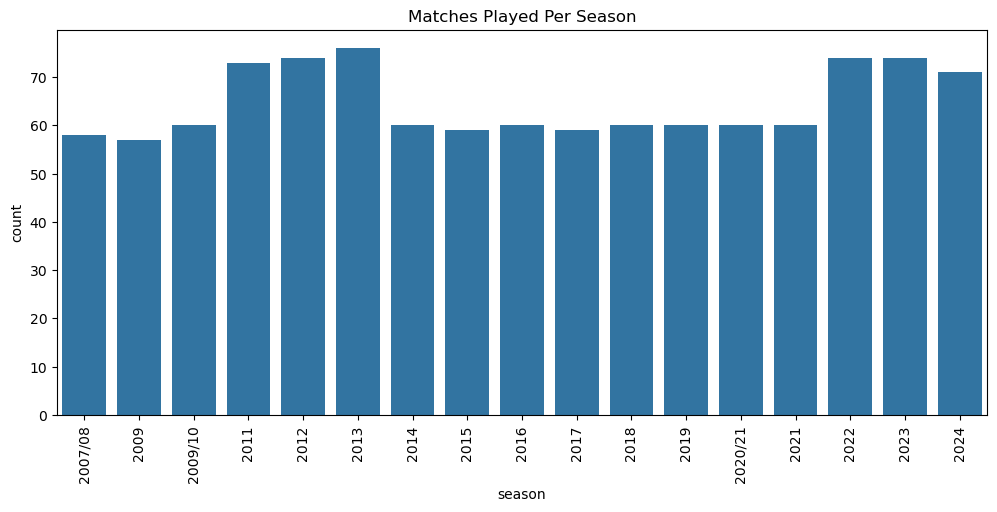

In [50]:
# Visualize matches played each season

plt.figure(figsize=(12,5))
sns.countplot(data=matches,x="season")
plt.xticks(rotation=90)
plt.title("Matches Played Per Season")
plt.show()

In [52]:
# Find top run scorers

top_batsmen = df.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

top_batsmen

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

In [54]:
# Find top wicket takers

top_bowlers = deliveries[deliveries["is_wicket"]==1]["bowler"].value_counts().head(10)

top_bowlers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64

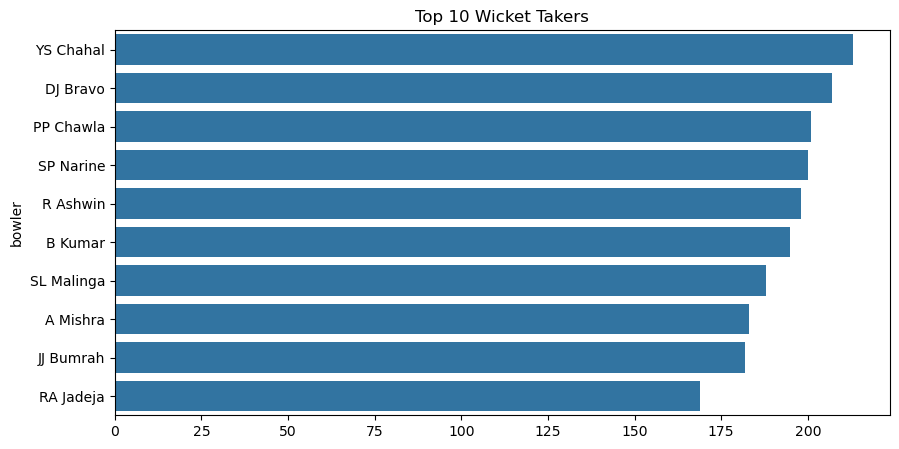

In [56]:
# Plot top wicket takers

plt.figure(figsize=(10,5))
sns.barplot(x=top_bowlers.values,y=top_bowlers.index)
plt.title("Top 10 Wicket Takers")
plt.show()

In [58]:
# Analyze toss decisions

matches["toss_decision"].value_counts()

toss_decision
field    704
bat      391
Name: count, dtype: int64

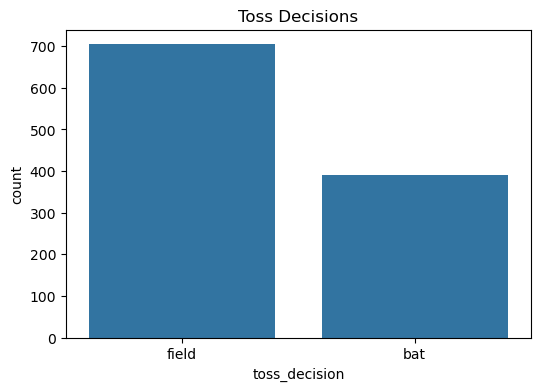

In [60]:
# Plot toss decision distribution

plt.figure(figsize=(6,4))
sns.countplot(data=matches,x="toss_decision")
plt.title("Toss Decisions")
plt.show()

In [62]:
# Find most successful teams

matches["winner"].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

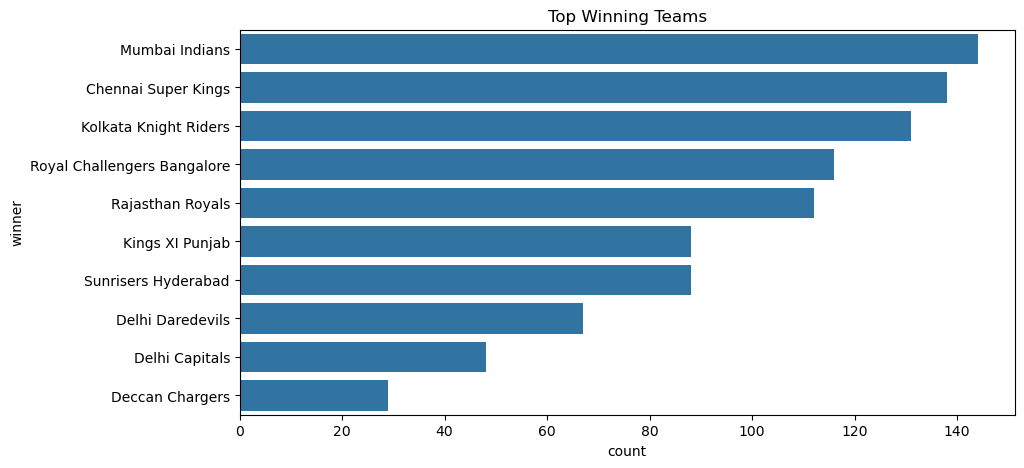

In [64]:
# Plot team wins

plt.figure(figsize=(10,5))
sns.countplot(
    data=matches,
    y="winner",
    order=matches["winner"].value_counts().head(10).index
)
plt.title("Top Winning Teams")
plt.show()